# How integrating over the centroid changes the moment distribution

A self-contained, toy-model walkthrough — pure `numpy`/`matplotlib`, no flow or data needed.

**The question.** In BFD we never know a galaxy's center exactly: it is found by nulling the first moments, leaving a residual *centering uncertainty* with covariance $C_X$. To stay unbiased we **integrate (marginalize) over the centroid**. What does that do to the measured moments — the size $M_r$ and the ellipticity $(M_1, M_2)$?

We build the intuition in five steps and recover, from first principles, the **dipole** that the conditional flow's `SigmaXCouplingLayer` needed to learn.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
rng = np.random.default_rng(1)

# Round Gaussian galaxy, unit flux, intrinsic per-axis variance sig2 = 1.
# Second moments about a center offset by delta=(u,v):  Q = sig2*I + delta delta^T
# Moment combos:  Mr = Qxx+Qyy ,  M1 = Qxx-Qyy ,  M2 = 2*Qxy
# Offset-INDUCED part (minus the delta=0 baseline) is purely quadratic in the offset:
def induced(delta):
    # returns dMr, dM1, dM2 injected by a center offset delta (last axis = (u,v))
    u = delta[..., 0]; v = delta[..., 1]
    return u**2 + v**2, u**2 - v**2, 2*u*v

## 1. Moments measured about an *offset* center

For a round Gaussian galaxy (unit flux, per-axis variance $\sigma^2$), the second-moment matrix measured about a point offset by $\boldsymbol\delta=(u,v)$ from the true center is exactly
$$Q(\boldsymbol\delta) = \sigma^2 I + \boldsymbol\delta\boldsymbol\delta^\top .$$
With $M_r=Q_{xx}+Q_{yy}$, $M_1=Q_{xx}-Q_{yy}$, $M_2=2Q_{xy}$, the **offset-induced** part is
$$\Delta M_r = u^2+v^2,\qquad \Delta M_1 = u^2-v^2,\qquad \Delta M_2 = 2uv .$$
Every induced term is **quadratic** in the offset. The cell below checks this against a brute-force pixel-grid measurement, then plots the moments as the center slides.

baseline pixel  Mr0=2.000 (expect 2)   M1=0.0e+00  M2=-1.1e-18
  offset=(0.8,0.0)  pixel(dM1,dM2)=(+0.640,+0.000)  analytic=(+0.640,+0.000)
  offset=(0.0,0.8)  pixel(dM1,dM2)=(-0.640,-0.000)  analytic=(-0.640,+0.000)
  offset=(0.5,0.5)  pixel(dM1,dM2)=(-0.000,+0.500)  analytic=(+0.000,+0.500)


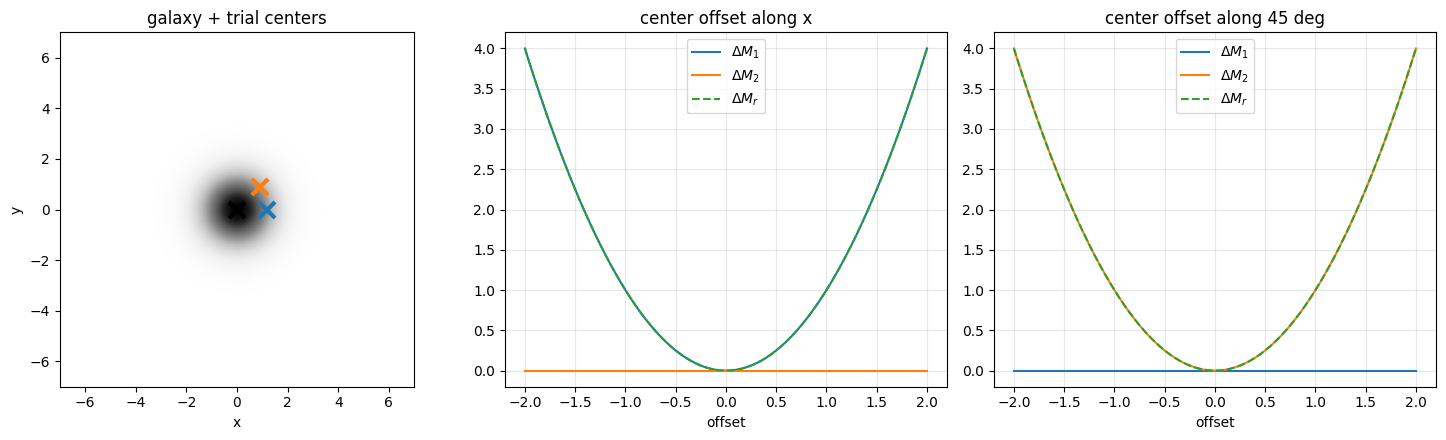

In [2]:
# Brute-force check on a pixel image, then plot moments vs offset.
n = 241; L = 7.0; xs = np.linspace(-L, L, n)
X, Y = np.meshgrid(xs, xs); sig = 1.0
Img = np.exp(-(X**2 + Y**2) / (2*sig**2)); Img /= Img.sum()

def pix_moments(cx, cy):
    Qxx = ((X-cx)**2 * Img).sum(); Qyy = ((Y-cy)**2 * Img).sum()
    Qxy = ((X-cx)*(Y-cy) * Img).sum()
    return Qxx+Qyy, Qxx-Qyy, 2*Qxy

Mr0, M10, M20 = pix_moments(0, 0)
print(f"baseline pixel  Mr0={Mr0:.3f} (expect 2)   M1={M10:.1e}  M2={M20:.1e}")
for (u, v) in [(0.8, 0.0), (0.0, 0.8), (0.5, 0.5)]:
    _, M1, M2 = pix_moments(u, v)
    _, a1, a2 = induced(np.array([u, v]))
    print(f"  offset=({u},{v})  pixel(dM1,dM2)=({M1-M10:+.3f},{M2-M20:+.3f})  analytic=({a1:+.3f},{a2:+.3f})")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].imshow(Img, extent=(-L, L, -L, L), origin="lower", cmap="Greys")
for (u, v), c in [((0, 0), "k"), ((1.2, 0), "C0"), ((0.9, 0.9), "C1")]:
    ax[0].plot(u, v, "x", color=c, ms=12, mew=3)
ax[0].set_title("galaxy + trial centers"); ax[0].set_xlabel("x"); ax[0].set_ylabel("y")
uu = np.linspace(-2, 2, 81)
for a, d, ttl in [(ax[1], np.stack([uu, 0*uu], -1), "center offset along x"),
                  (ax[2], np.stack([uu/np.sqrt(2), uu/np.sqrt(2)], -1), "center offset along 45 deg")]:
    dMr, dM1, dM2 = induced(d)
    a.plot(uu, dM1, label=r"$\Delta M_1$"); a.plot(uu, dM2, label=r"$\Delta M_2$")
    a.plot(uu, dMr, "--", label=r"$\Delta M_r$")
    a.set_title(ttl); a.set_xlabel("offset"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. The offset → ellipticity map is *spin-2*

$(\Delta M_1,\Delta M_2)=(u^2-v^2,\,2uv)$ is the **spin-2 square** of the offset vector: if $\boldsymbol\delta = \rho(\cos\theta,\sin\theta)$ then $(\Delta M_1,\Delta M_2)=\rho^2(\cos 2\theta,\,\sin 2\theta)$. Two facts we will use:

- the induced ellipticity goes around **twice** as the offset goes around once;
- **opposite offsets $\boldsymbol\delta$ and $-\boldsymbol\delta$ give the *same* ellipticity shift.**

That second fact is the whole reason the next step does not average to zero.

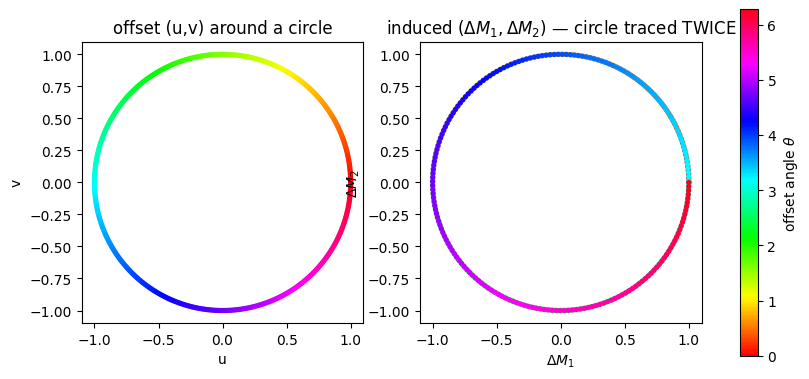

In [3]:
# Offsets around a circle -> induced ellipticity goes around TWICE (delta and -delta coincide).
th = np.linspace(0, 2*np.pi, 400)
d = np.stack([np.cos(th), np.sin(th)], -1)
_, dM1, dM2 = induced(d)
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))
ax[0].scatter(d[:, 0], d[:, 1], c=th, cmap="hsv", s=8)
ax[0].set_aspect("equal"); ax[0].set_title("offset (u,v) around a circle")
ax[0].set_xlabel("u"); ax[0].set_ylabel("v")
sc = ax[1].scatter(dM1, dM2, c=th, cmap="hsv", s=8)
ax[1].set_aspect("equal"); ax[1].set_title(r"induced $(\Delta M_1,\Delta M_2)$ — circle traced TWICE")
ax[1].set_xlabel(r"$\Delta M_1$"); ax[1].set_ylabel(r"$\Delta M_2$")
fig.colorbar(sc, ax=ax, label=r"offset angle $\theta$"); plt.show()

## 3. Marginalize over the centroid: $\boldsymbol\delta\sim\mathcal N(0,C_X)$

Parameterize the centering covariance by a scale (trace $T$) and an ellipticity $(e_1,e_2)$:
$$C_X = \tfrac{T}{2}\begin{pmatrix}1+e_1 & e_2\\ e_2 & 1-e_1\end{pmatrix}.$$
Because the induced moments are **quadratic**, their average over the offset distribution is fixed by the *covariance* of $\boldsymbol\delta$:
$$\mathbb E[\Delta M_1]=C_{xx}-C_{yy}=T\,e_1,\quad \mathbb E[\Delta M_2]=2C_{xy}=T\,e_2,\quad \mathbb E[\Delta M_r]=T .$$

- **Isotropic** $C_X$ ($e=0$): **no mean shift** in $(M_1,M_2)$ — only symmetric **broadening** plus size inflation $\langle\Delta M_r\rangle=T$. A *monopole*.
- **Elliptical** $C_X$ ($e\neq0$): a genuine **mean shift** $\langle(\Delta M_1,\Delta M_2)\rangle = T\,(e_1,e_2)$ — a **dipole**, which survives precisely because $\boldsymbol\delta$ and $-\boldsymbol\delta$ push the ellipticity the *same* way.

e=(0.0,0.0)  MC mean (dM1,dM2)=(-0.0019,-0.0045)  analytic T*(e1,e2)=(+0.0000,+0.0000)
e=(0.0,0.4)  MC mean (dM1,dM2)=(+0.0028,+0.2025)  analytic T*(e1,e2)=(+0.0000,+0.2000)


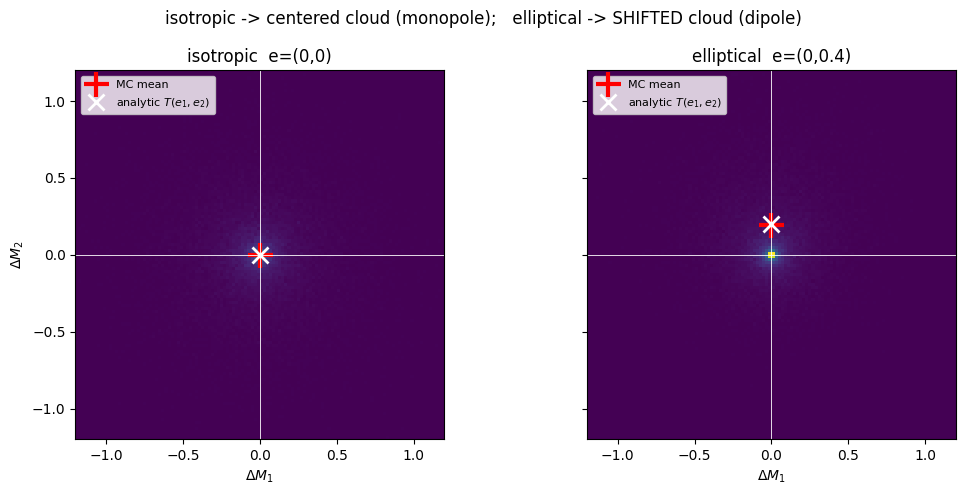

In [4]:
def CX(T, e1, e2):
    return (T/2.0) * np.array([[1+e1, e2], [e2, 1-e1]])

def sample_offsets(T, e1, e2, N):
    return rng.multivariate_normal([0, 0], CX(T, e1, e2), size=N)

T, N = 0.5, 60000
for (e1, e2) in [(0.0, 0.0), (0.0, 0.4)]:
    _, dM1, dM2 = induced(sample_offsets(T, e1, e2, N))
    print(f"e=({e1},{e2})  MC mean (dM1,dM2)=({dM1.mean():+.4f},{dM2.mean():+.4f})  "
          f"analytic T*(e1,e2)=({T*e1:+.4f},{T*e2:+.4f})")

fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for a, (ttl, (e1, e2)) in zip(ax, [("isotropic  e=(0,0)", (0, 0)), ("elliptical  e=(0,0.4)", (0.0, 0.4))]):
    _, dM1, dM2 = induced(sample_offsets(T, e1, e2, N))
    a.hist2d(dM1, dM2, bins=120, range=[[-1.2, 1.2], [-1.2, 1.2]], cmap="viridis")
    a.plot(dM1.mean(), dM2.mean(), "r+", ms=18, mew=3, label="MC mean")
    a.plot(T*e1, T*e2, "wx", ms=11, mew=2, label=r"analytic $T(e_1,e_2)$")
    a.set_aspect("equal"); a.set_title(ttl); a.set_xlabel(r"$\Delta M_1$")
    a.axhline(0, c="w", lw=.6); a.axvline(0, c="w", lw=.6); a.legend(loc="upper left", fontsize=8)
ax[0].set_ylabel(r"$\Delta M_2$")
fig.suptitle("isotropic -> centered cloud (monopole);   elliptical -> SHIFTED cloud (dipole)")
plt.tight_layout(); plt.show()

## 4. The dipole is linear in the centering ellipticity

The mean shift $\langle\Delta M_2\rangle = T\,e_2$ grows **linearly** with $e_2$ — it is the leading, $O(e)$ effect. The *anisotropy of the broadening* is the smaller $O(e^2)$ correction. So the dominant consequence of an elliptical centering uncertainty is a coherent, first-order ellipticity offset.

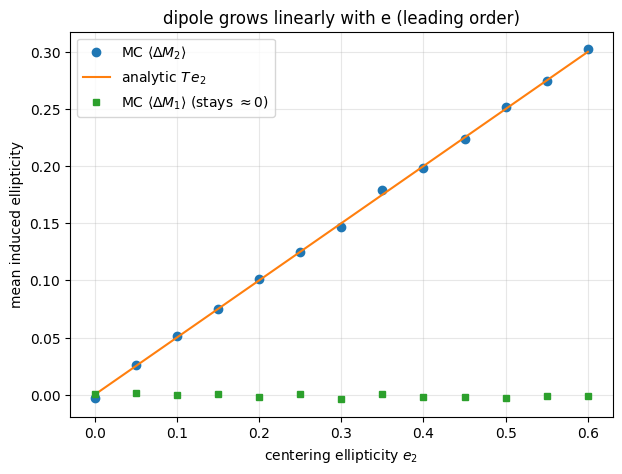

In [5]:
e2s = np.linspace(0, 0.6, 13)
m1s, m2s = [], []
for e2 in e2s:
    _, dM1, dM2 = induced(sample_offsets(T, 0.0, e2, N))
    m1s.append(dM1.mean()); m2s.append(dM2.mean())
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(e2s, m2s, "o", label=r"MC $\langle\Delta M_2\rangle$")
ax.plot(e2s, T*e2s, "-", label=r"analytic $T\,e_2$")
ax.plot(e2s, m1s, "s", ms=4, label=r"MC $\langle\Delta M_1\rangle$ (stays $\approx 0$)")
ax.set_xlabel(r"centering ellipticity $e_2$"); ax.set_ylabel("mean induced ellipticity")
ax.set_title("dipole grows linearly with e (leading order)"); ax.legend(); ax.grid(alpha=.3)
plt.show()

## 5. Population view — and the connection to the flow's $\Delta P$

For a population with intrinsic ellipticity distribution $P_{\rm intrinsic}(M_1,M_2)$, marginalizing over the centroid **convolves** it with the distribution of induced shifts. Below:

- *intrinsic* vs *isotropic-marginalized* $\to$ a **monopole** (broadening);
- $P_{\rm elliptical}-P_{\rm isotropic}$ at **fixed scale** $T$ $\to$ isolates the **dipole**.

That last panel is exactly the comparison the conditional flow makes, $P(e_2{=}0.2)-P(e_2{=}0)$, and the dipole here is the structure the `SigmaXCouplingLayer` had to (and now does) represent.

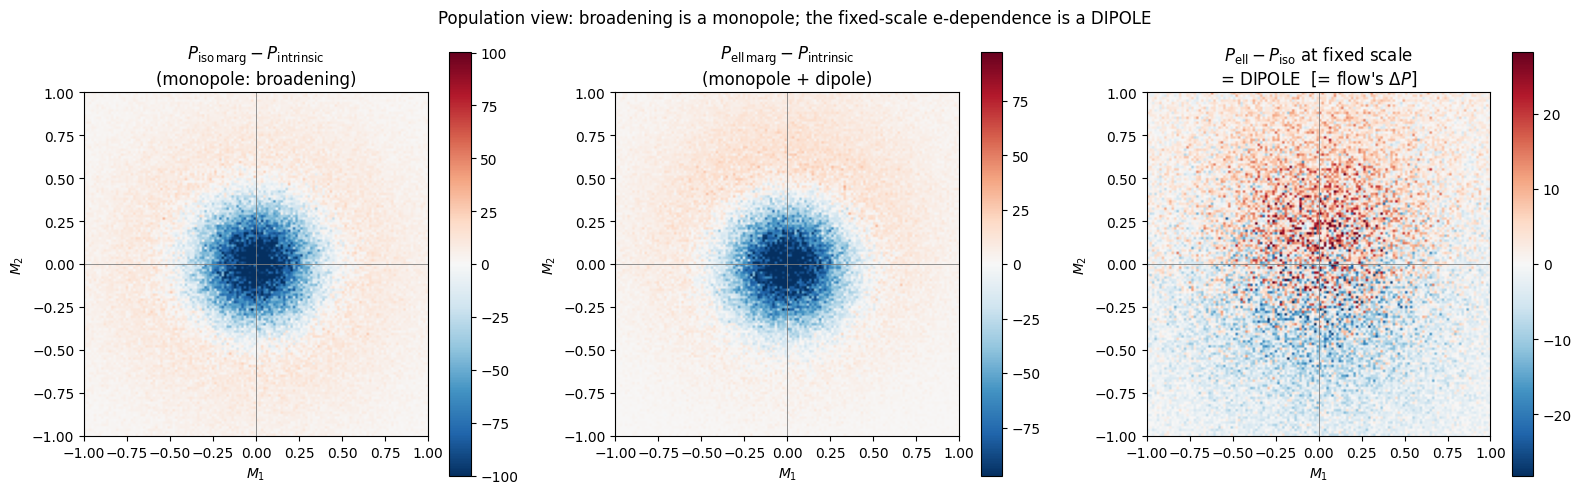

In [6]:
Npop, intr_sig = 400000, 0.25
intr = rng.normal(0, intr_sig, size=(Npop, 2))          # intrinsic (M1, M2)
edges = np.linspace(-1.0, 1.0, 141)
def hist(m):
    h, _, _ = np.histogram2d(m[:, 0], m[:, 1], bins=[edges, edges]); return h.T   # [M2, M1]
def marg_hist(e1, e2):
    _, dM1, dM2 = induced(sample_offsets(T, e1, e2, Npop))
    return hist(intr + np.stack([dM1, dM2], -1))

H0    = hist(intr)
H_iso = marg_hist(0.0, 0.0)
H_ell = marg_hist(0.0, 0.4)
ext = (-1, 1, -1, 1)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
panels = [(H_iso - H0,    r"$P_{\rm iso\,marg}-P_{\rm intrinsic}$" + "\n(monopole: broadening)"),
          (H_ell - H0,    r"$P_{\rm ell\,marg}-P_{\rm intrinsic}$" + "\n(monopole + dipole)"),
          (H_ell - H_iso, r"$P_{\rm ell}-P_{\rm iso}$ at fixed scale" + "\n= DIPOLE  [= flow's $\\Delta P$]")]
for a, (dP, ttl) in zip(ax, panels):
    v = np.abs(dP).max() * 0.6
    im = a.imshow(dP, extent=ext, origin="lower", cmap="RdBu_r", vmin=-v, vmax=v)
    a.set_title(ttl); a.set_xlabel(r"$M_1$"); a.set_ylabel(r"$M_2$")
    a.axhline(0, c="grey", lw=.6); a.axvline(0, c="grey", lw=.6); fig.colorbar(im, ax=a)
fig.suptitle("Population view: broadening is a monopole; the fixed-scale e-dependence is a DIPOLE")
plt.tight_layout(); plt.show()

## 6. Why this matters: degeneracy with shear

Lensing shear also shifts the mean ellipticity coherently, $\langle(M_1,M_2)\rangle \propto \mathbf g$. An **elliptical centering uncertainty produces the same kind of additive ellipticity** — so if the prior cannot represent the centering dipole, that signal leaks into the inferred shear as additive/multiplicative bias. This is why the prior must carry an **additive, $e$-linear term** (the dipole), not merely a width/stretch — exactly the term added to `SigmaXCouplingLayer`.

### Takeaways
1. A centroid offset injects moments **quadratic** in the offset (spin-1 ⊗ spin-1 → spin-0 size + spin-2 ellipticity).
2. Marginalizing an **isotropic** centering uncertainty → **broadening + size inflation** (a monopole), with *no* mean shift.
3. Marginalizing an **elliptical** one → a **mean ellipticity shift** $T(e_1,e_2)$ (a dipole), leading order in $e$, because opposite offsets add rather than cancel.
4. That dipole is **degenerate with shear**, so it must be modeled to keep shear unbiased.